# Python program indictaing the brain regions associated with psychological phenomenon
- Korosh Rajaei  
- Date of completion: November 25, 2025  
- [Link to the Neurosynth reward anticipation page](https://neurosynth.org/analyses/terms/reward%20anticipation/)  
  

In this project, I have written a pyhton program that shows the brain areas activated in reward anticipation. However, I wrote the program in a way that is flexible to be used with different psychological data from Neurosynth. Here, I show that reward anticipation is mostly associated with ventral striatum, nucleus accumbens, and ventral tegmental area.  
  
The code is in line with the functional programming paradigm. Also, it is written in a way to ensure that when faced with error, the user is aware of what is the source of the issue and how they can fix the issue. It is also written to be in line with software testing of its perfromance under different conditions.  
  
The notebook was coded in VSCode IDE and Conda environment. The cells were formatted using the Black Formatter extention to be in line with PEP8.

## Installing the required packages
Packages include:
- nibabel
- nilearn
- matplotlib
- numpy
- pathlib

In [20]:
# Uncomment if you do not have any of these packages installed
# !pip install nibabel
# !pip install nilearn
# !pip install matplotlib
# !pip install numpy
# !pip install pathlib

## Importting the installed and required packages  
Here we import the aforementioned required packages. The names of imported functions are based on the official documentation (e.g., numpy as np).

In [13]:
# Importing the required packages.
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

## Python functions and codes for Data visulization and Analysis  
As explained here, in this notebook and program, I used the functional programming paradigm and each module is put in a block of code or function. Therefore this makes the notebook also be applicable to different situations and it can be used to analyze other psyhcological phenomenon in Neurosynth. I tried to make each function error-proof by using try-except for situations and parts of the code that may run into errors. In this cases the user will be notified where the issue arises and how they can fix it. Also for all functions the user will be notified when the function has started and when it is ended to ensure no premature stopping of the program. 

### Function for automatically locating functional and anatomical data files  
Here, the FindDataFiles function does not take any inputs and it return the file paths of functional and anatomical data files to be later used in other functions. The function first in the same directory as the notebook (Path function), looks for two files that have in their names terms "anatomical" and "uniformity" and the extention ".nii.gz" (in line with Neurosynth data files). This is possible by using the glob function where it returns a genrator object in which later by uisng the next function (since the generator is an iterable) return the first file path that exists (based on our defined properties). The function (by using try-except) also takes into account the situation where the user might have not put the anatomical and functional data files in the same. In this case the program will not run into error and it will simply notify the user about the issue and ends the function.

In [ ]:
def FindDataFiles():
    # This function automatically finds and locates functional and anatomical data files based on file names and file extentions and return the both file paths.
    print(
        "FindDataFiles function starts...."
    )  # Letting the user know the function has started working.
    try:
        anatomical_file_dir = next(
            Path(".").glob("*anatomical*.nii.gz")
        )  # Locating the anatomical data by finding the first file in the same directory as the notebook that has in its name the term anatomical and end with the extention .noo.gz
        functional_file_dir = next(
            Path(".").glob("*uniformity*.nii.gz")
        )  # Locating the functional data by finding the first file in the same directory as the notebook that has in its name the term functional and end with the extention .noo.gz
        print(
            f"Files found successfully!\nFound anatomical file: {anatomical_file_dir}\nFound functional file:{functional_file_dir}"
        )  # Letting the user know we have located both data
        return (
            anatomical_file_dir,
            functional_file_dir,
        )  # Return the file path of both data
    except:
        print(
            "The current path does not have all the necessary files and data."
        )  # In the case of an error, for instance due to not finding the file, letting the user know to check their directory.
    finally:
        print(
            "FindDataFiles function ends...."
        )  # Letting the user know the function is ending here.

### Function for Visualizing the functional data on top of the anatomical scan  
The VisualizeFunctionalBrain function visualizes the functional data of the psychological phenomenon on top of the anatomical scan of the brain. Therefore it shows the areas of the brain that are activated (and by what extend) durig a psychological concept. The function takes as input the anatomical and functional data file paths (retreived using the previous function), voxel threshold value (min voxel value to be displayed) as an integer, coordinates of interest (where the psyhcological concept is most indicated) as a tuple of 3 integer values (x,y,z), color map type (as a string; which has to be in line with the plotting function design), and plot title as a string which will be displayed at the top of the plot. The function first loads the data using the nibabel package, then plots the visualization based on the input values and the data. For two blockes of code an error prevention try-except is applied. One for loading part and the other for the plotting stage.

In [15]:
def VisualizeFunctionalBrain(
    anat_path,
    func_path,
    threshold_val=0,
    coordinates=(0, 0, 0),
    cmap_type="hot",
    plot_title="",
):
    # This function gets the path to anaomical and functional data and other optional setting and then visualizes the functional data on top of the anatomical scan.
    # The fucntion has the ability to receive extra inputs for adjusting the plot and since these extra inputs are optional, the parameters have default values.
    print(
        "function VisualizeFunctionalBrain starts..."
    )  # Letting the user know the function has started working.
    try:
        anatomical_image = nib.load(
            anat_path
        )  # Loading the anatomical data using nibabel.
        functional_image = nib.load(
            func_path
        )  # Loading the functional data using nibabel.
        try:
            # Visualizing the functional data on top of the anatomical scan for our pyschological phenomenon of interest.
            display = plotting.plot_stat_map(
                functional_image,
                bg_img=anatomical_image,
                threshold=threshold_val,
                display_mode="ortho",
                cut_coords=coordinates,
                cmap=cmap_type,
                title=plot_title,
            )
            plotting.show()
        except:
            print(
                "Problem with running the plotting.plot_stat_map function... Check again your input values!"
            )  # Letting the user know in the case of an error due to plotting function (e.g. wrong input values).
    except:
        print(
            "Problem with the file paths! Could not load the functional or anatomical data! It could also be due to errors in package loading!"
        )  # Letting the user know in the case of an error due to loading the data (e.g. data not in the path).
    finally:
        print(
            "function VisualizeFunctionalBrain ends..."
        )  # Letting the user know the function is ending here.

### Function for plotting the voxel values histogram
The PlotVoxelValuesHistogram now will be used to plot a histogram of the voxel values in the functional data. The function takes as input only the functional data file path (retreived using the first function) and plots the histogram. First, the function loads the functional data using nibabel's load function. Then it extracts the voxel values using the get_fdata() function. Then, only the positive voxel values are stored and using these positive voxel values, the histogram is plotted (using matplotlib).

In [ ]:
def PlotVoxelValuesHistogram(funct_path):
    # This function plots the postitive values in the functional data file.
    print(
        "function PlotVoxelValuesHistogram starts..."
    )  # Letting the user know the function has started working.
    try:
        functional_image = nib.load(
            funct_path
        )  # Loading the functional data using nibabel.
        functional_values = (
            functional_image.get_fdata()
        )  # Getting the functional data array using the functional array image (that was loaded using nibabel in the previous line).
        positive_values = functional_values[
            functional_values > 0
        ]  # Only storing the positive values in the designated variable.
        print(
            "Max voxel value: {}".format(max(positive_values))
        )  # Printing the max voxel value (the most activated region by the psychological concept).
        plt.figure(
            figsize=(10, 10)
        )  # Creating a figure object with sizes of 10 for the both height and width.
        plt.hist(
            positive_values, color="skyblue"
        )  # Plotting the histogram of the positive values with the skyblue color.
        plt.title(
            "Histogram of Positive Functional Data Values"
        )  # Adding the title to the plot figure.
        plt.xlabel("Voxel value")  # Adding the x-axis label.
        plt.ylabel("Number of voxels")  # Adding the y-axis label.
        plt.show()  # plotting the histogram.
    except:
        print(
            "Problem with plotting the histogram! Either due to not being able to load the functional data or errors in package loading!"
        )  # Letting the user know in case there is an error in the plotting stage.
    finally:
        print(
            "function PlotVoxelValuesHistogram ends..."
        )  # Letting the user know the function is ending here.

## The actual python program containing the figures, visualizations and analysis  
Here, at first values associated with the project are assigned. The user is welcomed at first by the title and the output. Then user's inputs and stored in respective variables (threshold, coordinates of interest, and title). All the aforementioned functions are run in order and the output figure are shown to the user.

Hello and welcome!
--- Brain regions associated with reward anticipation ---
Here, we want to see which brain areas are activated in the case of reward anticipation.


-----------File/data loading-----------
FindDataFiles function starts....
Files found successfully!
Found anatomical file: anatomical.nii.gz
Found functional file:reward anticipation_uniformity-test_z_FDR_0.01.nii.gz
FindDataFiles function ends....

-----------Visualization of brain areas-----------
function VisualizeFunctionalBrain starts...


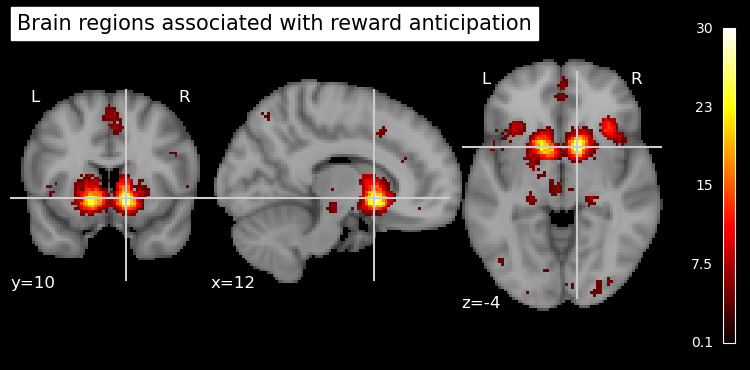

function VisualizeFunctionalBrain ends...

-----------Plotting histogram-----------
function PlotVoxelValuesHistogram starts...
Max voxel value: 30.113149040104382


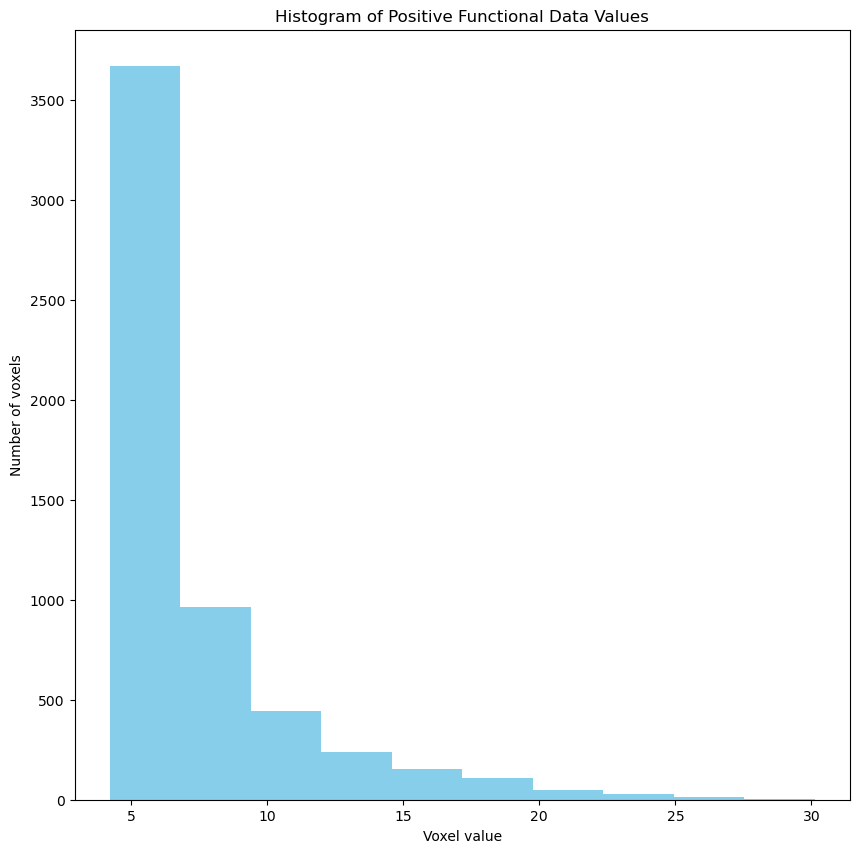

function PlotVoxelValuesHistogram ends...


In [18]:
# Input values to be changed based on the user's preferences and goals.
project_title = "Brain regions associated with reward anticipation"  # Project title that will be displayed also in the visualized brain areas figure.
project_description = "Here, we want to see which brain areas are activated in the case of reward anticipation."  # A short description of the project.
coordinates_of_interest = (
    12,
    10,
    -4,
)  # Voxel coordinates (x,y,z) that best indicate the psychological phenomenon.
voxel_value_threshold = 0.1  # Threshold value
print(
    f"Hello and welcome!\n--- {project_title} ---\n{project_description}\n"
)  # Welcoming the user and observers with the project title and description.
print("\n-----------File/data loading-----------")
# The data loading stage, the FindDataFiles function is called and the file paths of anatomical and functional data are stored in two variables.
anat_path, funct_path = FindDataFiles()
print("\n-----------Visualization of brain areas-----------")
# The brain area visualization stage where the VisualizeFunctionalBrain function is called and the file paths recieved from the previous function and the input values assigned earlier are passed to the function.
VisualizeFunctionalBrain(
    anat_path,
    funct_path,
    voxel_value_threshold,
    coordinates_of_interest,
    plot_title=project_title,
)
print("\n-----------Plotting histogram-----------")
# The histogram plotting stage, the PlotVoxelValuesHistogram function is called and the functional data path received from the first function is passed to this function.
PlotVoxelValuesHistogram(funct_path)

## Results  
The program successfully displays the figures.  
For my psychological phenomenon of interest which is award anticipation: ventral striatum, nucleus accumbens, and ventral tegmental area is specially active and has high voxel values. The highest voxel value is around 30.11 which is also the value of the coordinate I used here (12,10,-4) which is associated with ventral striatum/nucleus accumbens (important areas for the reward system). Most postitve voxels have the values between around 5 to 15.